In [2]:
from torch_snippets import *
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid

device = 'cuda' if torch.cuda.is_available() else 'cpu'

#dividindo em conjuntos de treinamento e teste
train_dataset = datasets.MNIST(root='~/data/MNIST/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='~/data/MNIST/', train=False, transform=transforms.ToTensor(), download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable

class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        
        #encoder
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 256)
        self.fc21 = nn.Linear(256, 20)
        self.fc22 = nn.Linear(256, 20) 
        
        #decoder
        self.fc3 = nn.Linear(20, 256)
        self.fc4 = nn.Linear(256, 64 * 7 * 7)
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.deconv2 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1)
        
    def encode(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        mu = self.fc21(x)
        logvar = self.fc22(x)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = Variable(torch.randn(std.size())).cuda()
            return eps.mul(std).add_(mu)
        else:
            return mu
    
    def decode(self, z):
        z = F.relu(self.fc3(z))
        z = F.relu(self.fc4(z))
        z = z.view(z.size(0), 64, 7, 7)
        z = F.relu(self.deconv1(z))
        z = torch.sigmoid(self.deconv2(z))
        return z
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        z = self.decode(z)
        return z, mu, logvar


In [5]:
# class VAE(nn.Module):
#     def __init__(self, x_dim, h_dim1, h_dim2, z_dim):
#         super(VAE, self).__init__()
#         self.d1 = nn.Linear(x_dim, h_dim1)
#         self.d2 = nn.Linear(h_dim1, h_dim2)
#         self.d31 = nn.Linear(h_dim2, z_dim)
#         self.d32 = nn.Linear(h_dim2, z_dim)
#         self.d4 = nn.Linear(z_dim, h_dim2)
#         self.d5 = nn.Linear(h_dim2, h_dim1)
#         self.d6 = nn.Linear(h_dim1, x_dim)
#     def encoder(self, x):
#         h = F.relu(self.d1(x))
#         h = F.relu(self.d2(h))
#         return self.d31(h), self.d32(h)
#     def sampling(self, mean, log_var):
#         std = torch.exp(0.5*log_var)
#         eps = torch.randn_like(std)
#         return eps.mul(std).add_(mean)
#     def decoder(self, z):
#         h = F.relu(self.d4(z))
#         h = F.relu(self.d5(h))
#         return F.sigmoid(self.d6(h))
#     def forward(self, x):
#         mean, log_var = self.encoder(x.view(-1, 784))
#         z = self.sampling(mean, log_var)
#         return self.decoder(z), mean, log_var

In [6]:
def train_batch(data, model, optimizer, loss_function):
    model.train()
    data = data.to(device)
    optimizer.zero_grad()
    recon_batch, mean, log_var = model(data)
    loss, mse, kld = loss_function(recon_batch, data, mean, log_var)
    loss.backward()
    optimizer.step()
    return loss, mse, kld, log_var.mean(), mean.mean()



@torch.no_grad()
def validate_batch(data, model, loss_function):
    model.eval()
    data = data.to(device)
    recon, mean, log_var = model(data)
    loss, mse, kld = loss_function(recon, data, mean, log_var)
    return loss, mse, kld, log_var.mean(), mean.mean()

In [7]:
def loss_function(recon_x, x, mean, log_var):
    RECON = F.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
    return RECON + KLD, RECON, KLD

EPOCH: 1.000  train_recon: 2297.355  val_kld: 553.400  train_log_var: -0.553  val_recon: 1341.733  train_loss: 2669.285  val_loss: 1895.134  train_mean: -0.002  val_log_var: -0.861  train_kld: 371.930  val_mean: -0.020  (6.01s - 54.05s remaining)


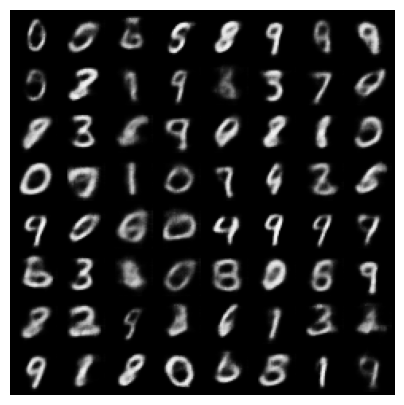

EPOCH: 2.000  train_recon: 1417.259  val_kld: 673.108  train_log_var: -0.954  val_recon: 1041.188  train_loss: 2032.749  val_loss: 1714.296  train_mean: 0.001  val_log_var: -1.052  train_kld: 615.490  val_mean: -0.005  (11.49s - 45.98s remaining)


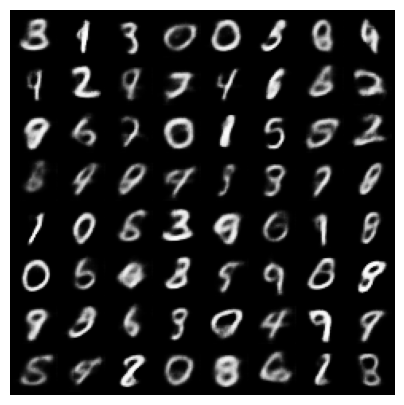

EPOCH: 3.000  train_recon: 1281.129  val_kld: 694.506  train_log_var: -1.025  val_recon: 957.046  train_loss: 1938.138  val_loss: 1651.552  train_mean: 0.001  val_log_var: -1.089  train_kld: 657.009  val_mean: 0.010  (17.37s - 40.53s remaining)


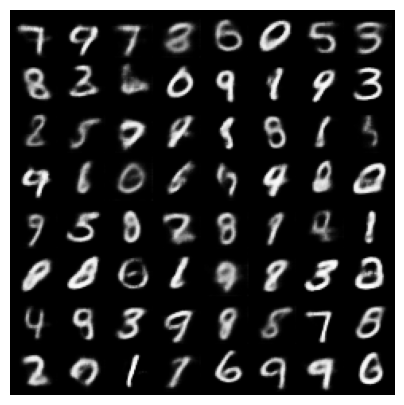

EPOCH: 4.000  train_recon: 1207.876  val_kld: 683.803  train_log_var: -1.062  val_recon: 903.712  train_loss: 1888.562  val_loss: 1587.515  train_mean: 0.001  val_log_var: -1.076  train_kld: 680.686  val_mean: -0.018  (22.91s - 34.36s remaining)


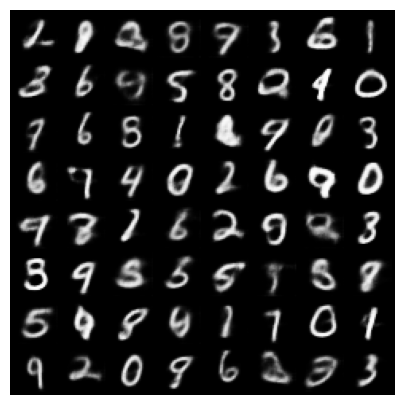

EPOCH: 5.000  train_recon: 1163.308  val_kld: 688.818  train_log_var: -1.087  val_recon: 861.540  train_loss: 1859.244  val_loss: 1550.359  train_mean: 0.001  val_log_var: -1.089  train_kld: 695.935  val_mean: -0.002  (28.62s - 28.62s remaining)


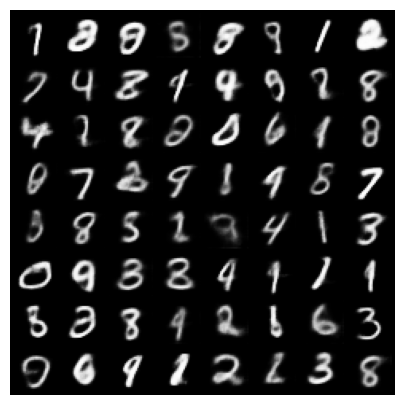

EPOCH: 6.000  train_recon: 1132.950  val_kld: 704.398  train_log_var: -1.105  val_recon: 837.791  train_loss: 1840.117  val_loss: 1542.189  train_mean: 0.002  val_log_var: -1.118  train_kld: 707.167  val_mean: 0.013  (34.54s - 23.02s remaining)


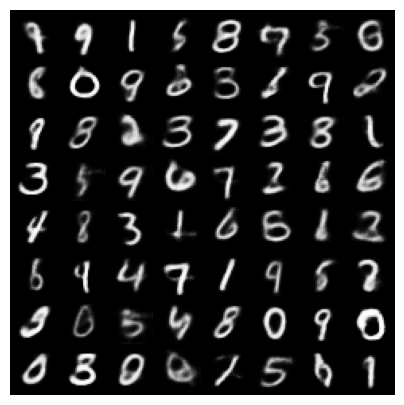

EPOCH: 7.000  train_recon: 1108.127  val_kld: 707.415  train_log_var: -1.118  val_recon: 817.878  train_loss: 1823.450  val_loss: 1525.294  train_mean: 0.001  val_log_var: -1.104  train_kld: 715.323  val_mean: 0.008  (40.30s - 17.27s remaining)


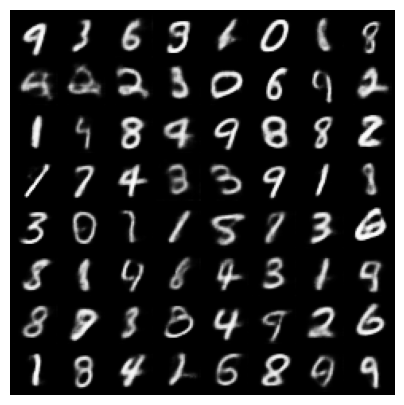

EPOCH: 8.000  train_recon: 1089.705  val_kld: 734.234  train_log_var: -1.126  val_recon: 796.543  train_loss: 1810.536  val_loss: 1530.777  train_mean: 0.001  val_log_var: -1.145  train_kld: 720.830  val_mean: 0.020  (46.01s - 11.50s remaining)


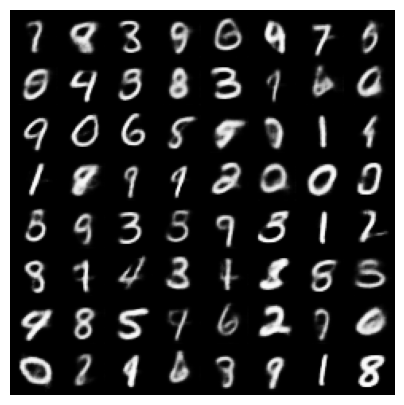

EPOCH: 9.000  train_recon: 1074.985  val_kld: 730.135  train_log_var: -1.133  val_recon: 789.094  train_loss: 1799.795  val_loss: 1519.230  train_mean: 0.001  val_log_var: -1.169  train_kld: 724.810  val_mean: -0.009  (51.73s - 5.75s remaining)


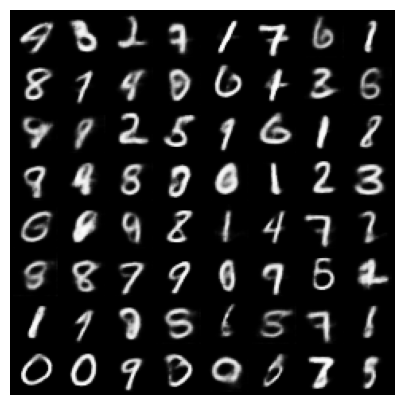

EPOCH: 10.000  train_recon: 1062.453  val_kld: 732.394  train_log_var: -1.141  val_recon: 772.281  train_loss: 1792.199  val_loss: 1504.675  train_mean: 0.000  val_log_var: -1.146  train_kld: 729.746  val_mean: 0.015  (57.54s - 0.00s remaining)


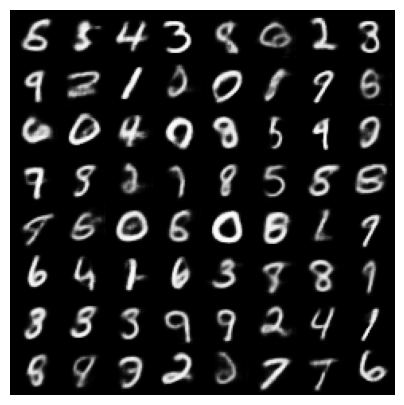

In [8]:
n_epochs = 10
log = Report(n_epochs)
vae = VAE().to(device)
optimizer = optim.AdamW(vae.parameters(), lr=1e-3)


for epoch in range(n_epochs):
    N = len(train_loader)
    for batch_idx, (data, _) in enumerate(train_loader):
        loss, recon, kld, log_var, mean = train_batch(data, vae, optimizer, loss_function)
        pos = epoch + (1+batch_idx)/N
        log.record(pos, train_loss=loss, train_kld=kld, train_recon=recon, train_log_var=log_var, train_mean=mean, end='\r')
        
    N = len(test_loader)
    for batch_idx, (data, _) in enumerate(test_loader):
        loss, recon, kld, log_var, mean = validate_batch(data, vae, loss_function)
        pos = epoch + (1+batch_idx)/N
        log.record(pos, val_loss=loss, val_kld=kld, val_recon=recon, val_log_var=log_var, val_mean=mean, end='\r')
        
    log.report_avgs(epoch+1)
    with torch.no_grad():
        z = torch.randn(64, 20).to(device)
        sample = vae.decode(z).to(device)
        images = make_grid(sample.view(64, 1, 28, 28)).permute(1,2,0)
        show(images)

  0%|          | 0/111 [00:00<?, ?it/s]

100%|██████████| 111/111 [00:00<00:00, 636.02it/s]


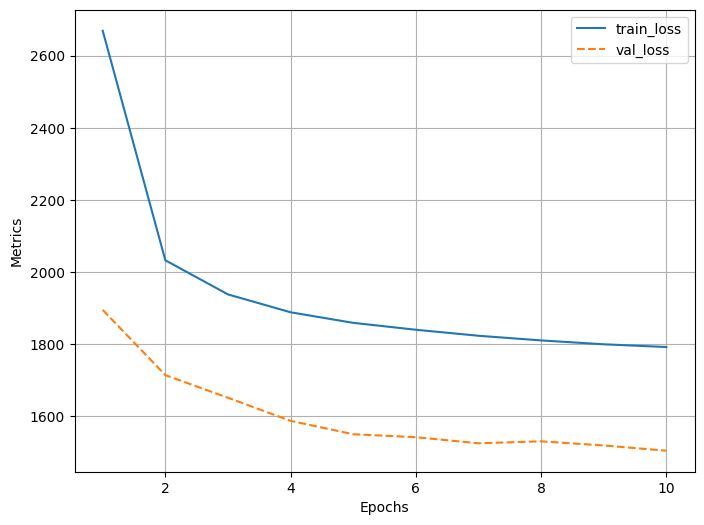

In [9]:
log.plot_epochs(['train_loss','val_loss'])